# Extended Forecastability Fingerprint Interpretation

This focused triage notebook reads the additive extended fingerprint blocks around the primary AMI forecastability cue.

It uses a small representative subset of the deterministic showcase panel so the interpretation stays compact while still covering a null baseline, seasonal reinforcement, persistence-across-scales reinforcement, and structured nonlinear reinforcement.

## AMI-first framing

The point of this notebook is not to replace lag geometry with a bag of auxiliary metrics. It is to show how spectral, ordinal, classical, and memory diagnostics help interpret the same deterministic AMI-first triage story.

No model fitting happens here. The notebook stops at interpretation and route-level guidance.

In [1]:
%matplotlib inline

from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from forecastability import run_extended_forecastability_analysis
from forecastability.reporting.extended_fingerprint_showcase import (
    build_extended_fingerprint_showcase_record,
    routing_table_frame,
    save_metric_overview,
    save_showcase_profile_grid,
    showcase_summary_frame,
    write_frame_csv,
)
from forecastability.utils.synthetic import generate_extended_fingerprint_showcase_panel

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.precision", 4)

In [2]:
OUTPUT_ROOT = Path("outputs/notebooks/triage_walkthroughs/07_extended_forecastability_fingerprint")
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_OBS = 360
MAX_LAG = 18
SEASONAL_PERIOD = 12
SELECTED_SERIES = (
    "white_noise",
    "seasonal_plus_noise",
    "long_memory_candidate",
    "henon_map",
)

OUTPUT_ROOT

PosixPath('outputs/notebooks/triage_walkthroughs/07_extended_forecastability_fingerprint')

## Representative subset

The subset below is chosen for interpretation coverage rather than exhaustiveness:

- `white_noise` keeps the null AMI baseline visible,
- `seasonal_plus_noise` shows periodic reinforcement around a usable lag cue,
- `long_memory_candidate` shows persistence-across-scales reinforcement,
- `henon_map` keeps the nonlinear structured case visible.

In [3]:
panel = generate_extended_fingerprint_showcase_panel(
    n=N_OBS,
    seed=SEED,
    seasonal_period=SEASONAL_PERIOD,
)
case_by_name = {case.series_name: case for case in panel}
selected_cases = [case_by_name[name] for name in SELECTED_SERIES]

subset_overview = pd.DataFrame(
    [
        {
            "series_name": case.series_name,
            "period": case.period,
            "description": case.description,
            "expected_story": case.expected_story,
        }
        for case in selected_cases
    ]
)
subset_overview

,series_name,period,description,expected_story
0,white_noise,NaN,IID Gaussian noise used as the AMI-first null baseline.,Lag geometry and the additive diagnostics should stay weak enough to keep the route on simple baseline families.
1,seasonal_plus_noise,12.0,Additive seasonal signal with moderate observational noise.,AMI should retain usable seasonal signal while the additive diagnostics show a noisier but still seasonal structure than the clean sine ...
2,long_memory_candidate,NaN,Persistent long-memory proxy blended with a short-range smooth component so the AMI-first lag cue remains visible.,AMI should retain a short lag-dependence cue while the memory block adds a persistence-across-scales cue rather than replacing the AMI-f...
3,henon_map,NaN,Nonlinear lag-product measurement derived from a deterministic Henon map trajectory.,AMI should remain the primary gate while ordinal redundancy provides the strongest nonlinear cue in the panel beyond the seasonal sine e...


## Run the extended analysis on the subset

The analysis cell below calls the packaged AMI-first use case and then builds compact interpretation tables from the returned result objects. No diagnostic logic is reimplemented in the notebook.

In [4]:
records = []
for case in selected_cases:
    analysis = run_extended_forecastability_analysis(
        case.series,
        name=case.series_name,
        max_lag=MAX_LAG,
        period=case.period,
        random_state=SEED,
    )
    records.append(
        build_extended_fingerprint_showcase_record(
            case=case,
            analysis=analysis,
        )
    )

summary_frame = showcase_summary_frame(records)
routing_frame = routing_table_frame(records)

compact_frame = pd.DataFrame(
    [
        {
            "target_name": record.series_name,
            "signal_to_noise": (
                None
                if record.analysis.fingerprint.information_geometry is None
                else record.analysis.fingerprint.information_geometry.signal_to_noise
            ),
            "information_horizon": (
                0
                if record.analysis.fingerprint.information_geometry is None
                else record.analysis.fingerprint.information_geometry.information_horizon
            ),
            "spectral_predictability": (
                None
                if record.analysis.fingerprint.spectral is None
                else record.analysis.fingerprint.spectral.spectral_predictability
            ),
            "periodicity_hint": (
                None
                if record.analysis.fingerprint.spectral is None
                else record.analysis.fingerprint.spectral.periodicity_hint
            ),
            "ordinal_redundancy": (
                None
                if record.analysis.fingerprint.ordinal is None
                else record.analysis.fingerprint.ordinal.ordinal_redundancy
            ),
            "complexity_class": (
                None
                if record.analysis.fingerprint.ordinal is None
                else record.analysis.fingerprint.ordinal.complexity_class
            ),
            "seasonal_strength": (
                None
                if record.analysis.fingerprint.classical is None
                else record.analysis.fingerprint.classical.seasonal_strength
            ),
            "trend_strength": (
                None
                if record.analysis.fingerprint.classical is None
                else record.analysis.fingerprint.classical.trend_strength
            ),
            "dfa_alpha": (
                None
                if record.analysis.fingerprint.memory is None
                else record.analysis.fingerprint.memory.dfa_alpha
            ),
            "memory_type": (
                None
                if record.analysis.fingerprint.memory is None
                else record.analysis.fingerprint.memory.memory_type
            ),
            "predictability_sources": 
            ", \
-",
        }
        for record in records
    ]
)

write_frame_csv(compact_frame, output_path=TABLE_DIR / "compact_interpretation.csv")
write_frame_csv(summary_frame, output_path=TABLE_DIR / "subset_summary.csv")
write_frame_csv(routing_frame, output_path=TABLE_DIR / "subset_routing.csv")

compact_frame

,target_name,signal_to_noise,information_horizon,spectral_predictability,periodicity_hint,ordinal_redundancy,complexity_class,seasonal_strength,trend_strength,dfa_alpha,memory_type,predictability_sources
0,white_noise,0.2188,0,0.0804,none,0.0047,noise_like,NaN,0.0015,0.4988,short_memory,", -"
1,seasonal_plus_noise,0.7831,18,0.4701,weak,0.0062,noise_like,0.6911,0.0028,0.5235,short_memory,", -"
2,long_memory_candidate,0.5659,4,0.1433,none,0.0086,noise_like,NaN,0.0081,0.9422,long_memory_candidate,", -"
3,henon_map,0.9696,18,0.1965,none,0.4041,complex_but_redundant,NaN,0.0003,0.2161,anti_persistent,", -"


## How to read the additive blocks around AMI

A useful reading order is:

1. Start with `signal_to_noise` and `information_horizon` to decide whether lag structure is usable at all.
2. Use `spectral_predictability` and `periodicity_hint` to check whether recurring structure reinforces a seasonal reading.
3. Use `ordinal_redundancy` and `complexity_class` to see whether the series looks structurally nonlinear rather than merely noisy.
4. Use `seasonal_strength` and `trend_strength` to decide whether classical period-aware structure or trend-dominated nonstationarity is a better explanation.
5. Use `dfa_alpha` and `memory_type` only as conservative persistence-across-scales context, not as a replacement for lag geometry.

In [5]:
display(
    routing_frame[[
        "target_name",
        "signal_strength",
        "noise_risk",
        "predictability_sources",
        "recommended_model_families",
        "avoid_model_families",
    ]]
)

,target_name,signal_strength,noise_risk,predictability_sources,recommended_model_families,avoid_model_families
0,white_noise,low,high,-,"naive, seasonal_naive, downscope","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular, tbats"
1,seasonal_plus_noise,high,medium,"lag_dependence, seasonality","arima, ets, linear_state_space, seasonal_naive, harmonic_regression, tbats, seasonal_state_space","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular"
2,long_memory_candidate,high,medium,"lag_dependence, long_memory","arima, ets, linear_state_space, long_window_ar, fractional_differencing_candidate","tree_on_lags, tcn, nbeats, nhits, nonlinear_tabular, tbats"
3,henon_map,high,medium,"lag_dependence, ordinal_redundancy","arima, ets, linear_state_space, tree_on_lags, nonlinear_tabular, tcn",tbats


## Simple visuals

The first figure keeps the AMI-first profile visible for the subset. The second figure places the additive metrics next to the AMI metrics so the reinforcement pattern is easier to compare at a glance.

Both are written to the sibling output tree when you run the notebook locally.

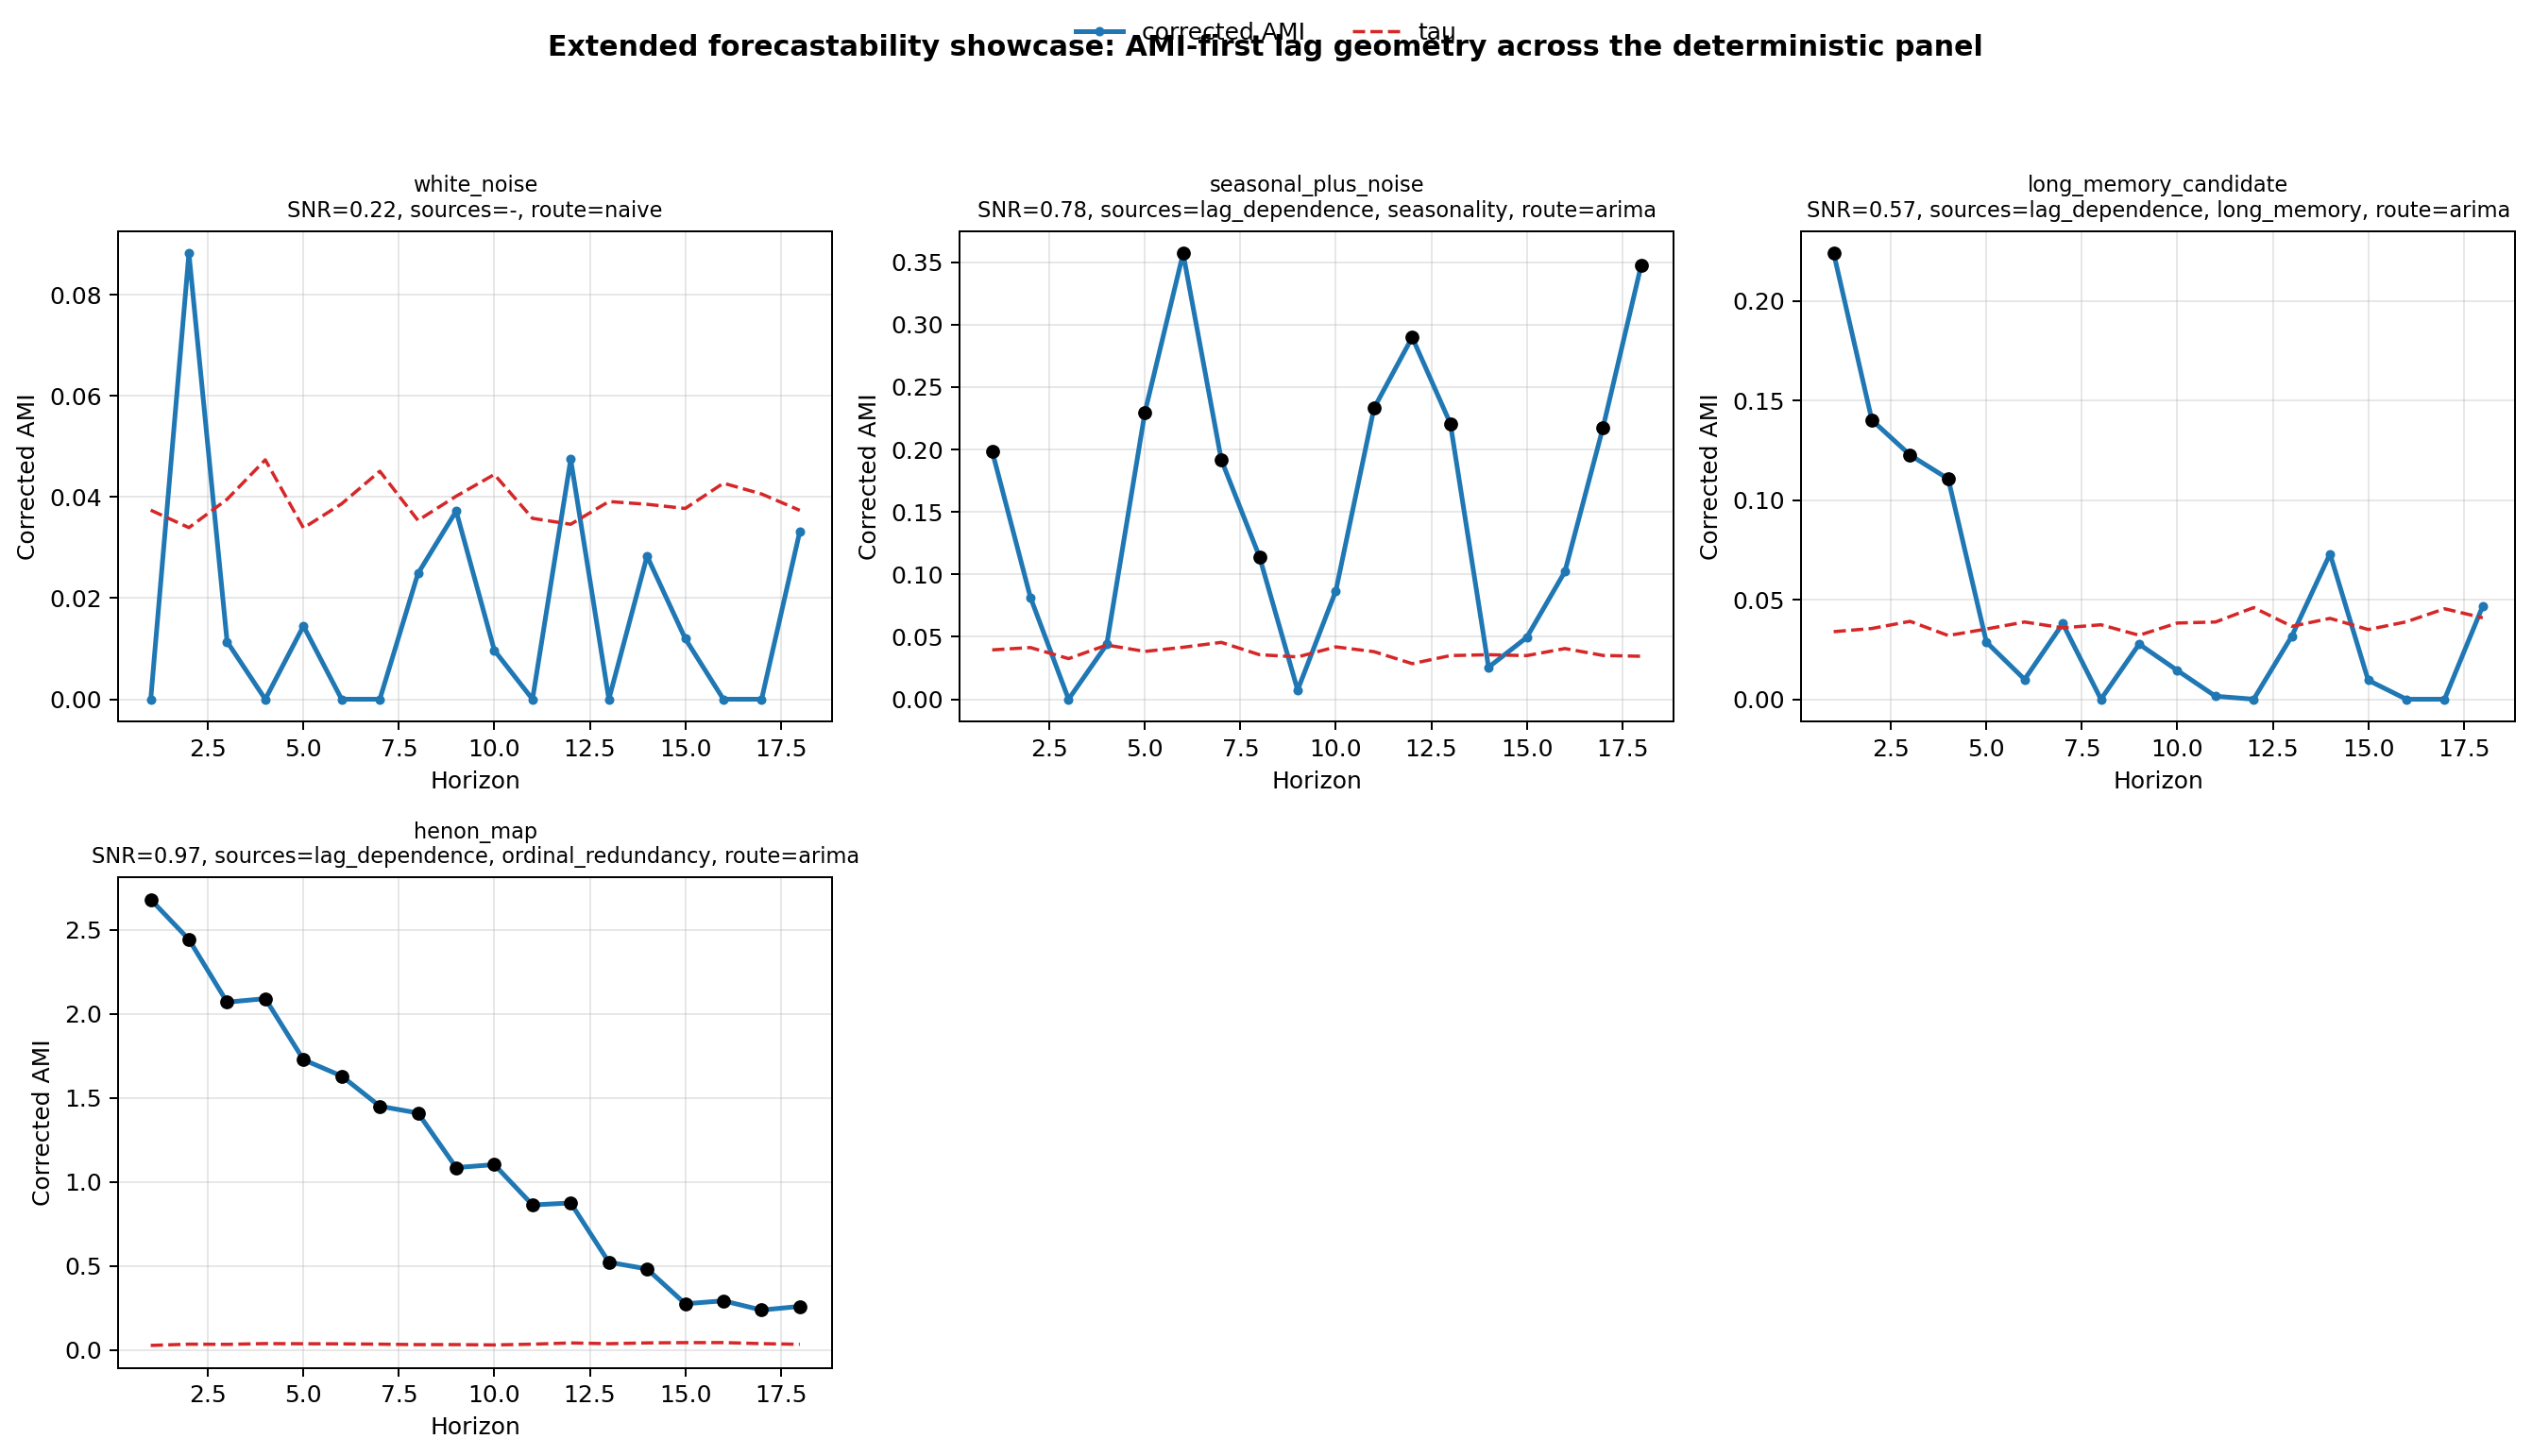

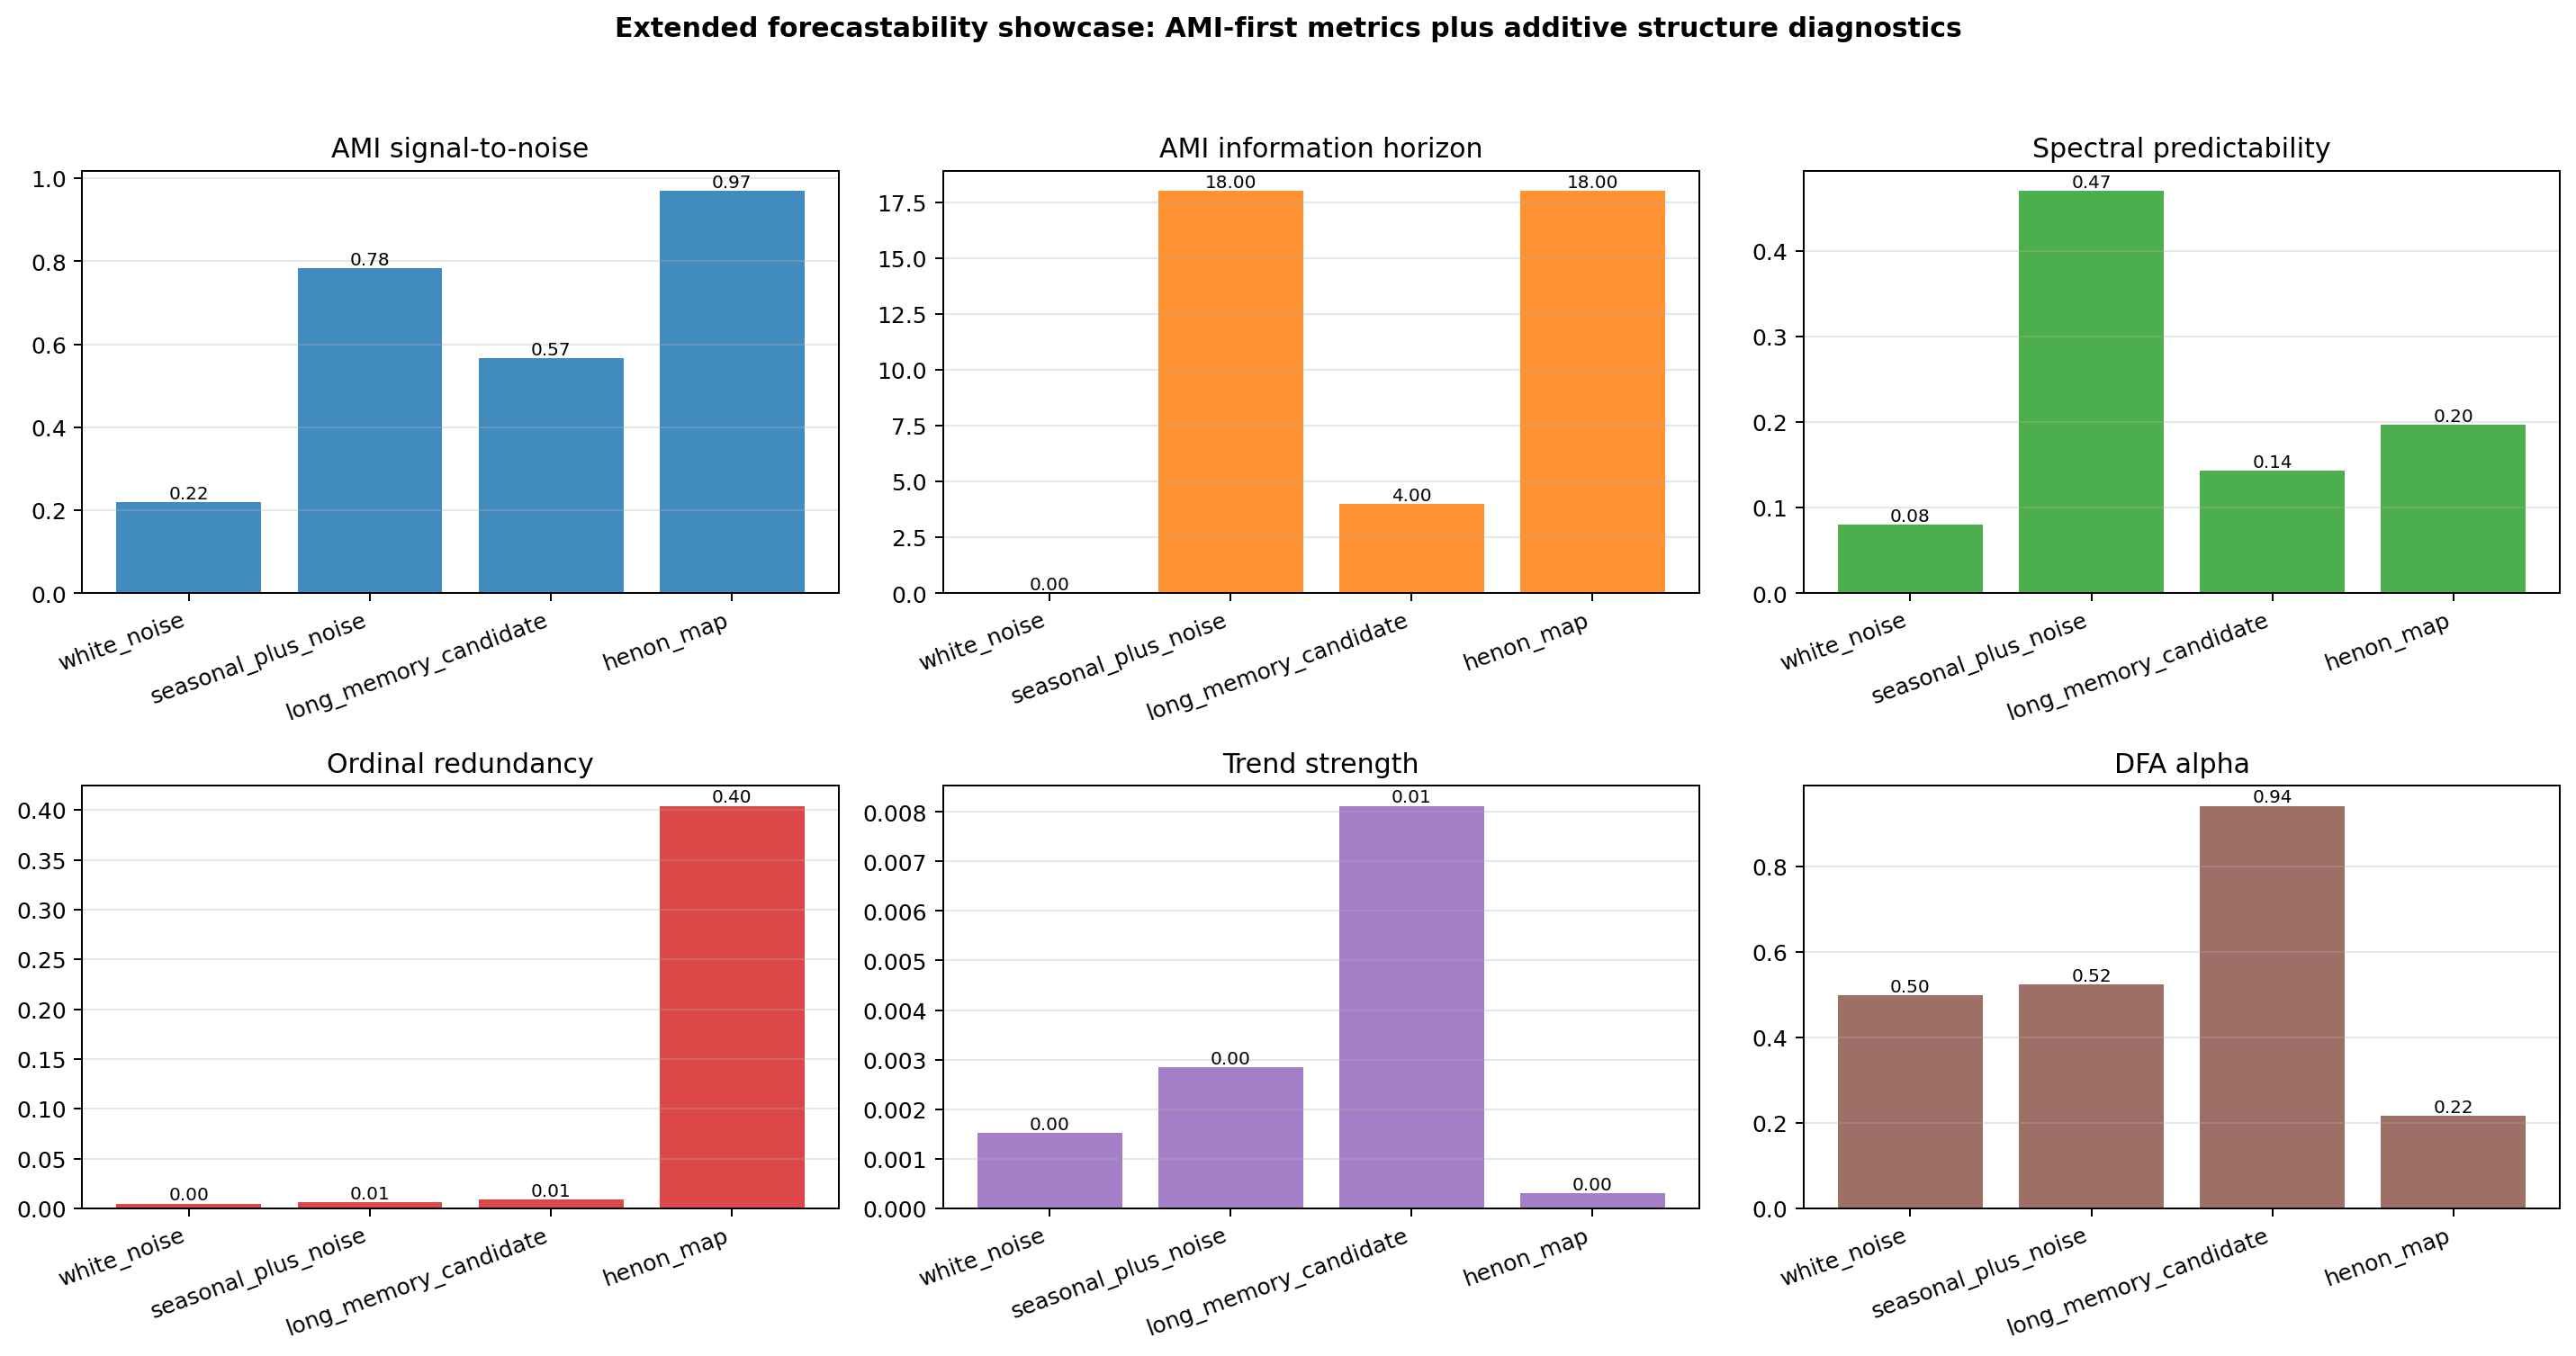

In [6]:
profile_path = FIG_DIR / "subset_ami_profiles.png"
metric_path = FIG_DIR / "subset_metric_overview.png"

save_showcase_profile_grid(records, output_path=profile_path)
save_metric_overview(records, output_path=metric_path)

display(Image(filename=str(profile_path)))
display(Image(filename=str(metric_path)))

## Caveats and hand-off boundary

This notebook is interpretive, subset-based, and synthetic. It is designed to help you read the additive blocks around AMI rather than to stand in for a full benchmark or an end-to-end forecasting workflow.

If you want to continue beyond this point, run the notebook locally, inspect the saved outputs under `outputs/notebooks/triage_walkthroughs/07_extended_forecastability_fingerprint/`, and then move to a separate downstream hand-off or forecast-prep surface.